# Bases Datos Vectoriales y RAG<a class="tocSkip">
## INTELIGENCIA ARTIFICIAL <a class="tocSkip">
### Ingenieria Electrónica <a class="tocSkip">
### Universidad Popular del Cesar <a class="tocSkip">
### Prof.: Jose Ramón Iglesias Gamarra - [https://github.com/joseramoniglesias/](https://github.com/joseramoniglesias/) <a class="tocSkip">
  **joseiglesias@unicesar.edu.co**

## Instalar Paquetes

In [1]:
!pip install langchain

In [2]:

!pip install -U langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.1 MB/s eta 0:00:00


In [4]:
!pip install pypdf

ERROR: Could not find a version that satisfies the requirement pypdf (from versions: none)
ERROR: No matching distribution found for pypdf


In [4]:
!pip install openai
!pip install --force-reinstall -v httpx==0.27.2

In [1]:
#Paquetes:
from langchain.document_loaders import PyPDFLoader
from langchain.chains.question_answering import load_qa_chain
from langchain_community.chat_models import ChatOpenAI
from langchain.prompts import PromptTemplate
from langchain.memory import ConversationBufferMemory

In [2]:
#Se carga el contenido del archivo pdf
loader=PyPDFLoader("data/puesta_a_tierra.pdf")
data=loader.load()

In [3]:
len(data) #Lista de objetcos, donde cada objetos tiene dos llaves: source y page_content

17

In [4]:
data[0].metadata

{'producer': 'Skia/PDF m133 Google Docs Renderer',
 'creator': 'PyPDF',
 'creationdate': '',
 'title': 'PUESTA A TIERRA.docx',
 'source': 'data/puesta_a_tierra.pdf',
 'total_pages': 17,
 'page': 0,
 'page_label': '1'}

In [5]:
data[0].page_content

'PUESTASATIERRA\nEn líneas provistas de cable deguardacada500metrosirápuestaatierra, ademásde todas aquellas que posean subestaciones, secciones y descargadores desobretensión.\nLa puesta a tierra debe ser único para cable de guarda, neutro, descargadores desobretensiónycarcazadel transformador.En todos los casos cuando la estructura sea existente se empleará cable de cobredesnudo con calibre no inferior al 4 AWGo cable de acero galvanizado de3/8” (50mm²), el cual podrá ser de grado común por la no exigencia de requerimientosmecánicos. Podrá además emplearse cualquier conductor aceptado por el RETIEsiempre y cuando su área permita laadecuadaconducciónatierradelascorrientesde cortocircuito calculadas para el respectivo sitio de conexión, no pudiendo serinferioralaestablecidaenel RETIE.\nEl conductor citadoserátendidosobrelaestructuraenlíneatotalmenterectadesdeelpunto de conexión en el cable de guarda o en los descargadores de sobretensiónhastasuconexiónconlavarilladepuestaatierra.\nAnte

## Text Splitters




In [6]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000, #Particionamos nuestro texto en fragmentos de 1000 tokens, donde cada fragmento será uns instancia de mi base de datos vectorizada (Esto depende de la cantidad máxima de tokens que puede procesar el modelo de embeddings a utilizar)
    chunk_overlap=200, #Paraca cada fragmento, tomamos los últimos 200 tokens del último fragmento para mantener el contexto en cada fragmento
    length_function=len #Función para contar la longitud de los fragmentos de texto
)

documents = text_splitter.split_documents(data)

In [7]:
len(documents) #De las 14 páginas que teniamos, extragimos 48 fragmentos de texto

54

In [8]:
documents[20]

Document(metadata={'producer': 'Skia/PDF m133 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'PUESTA A TIERRA.docx', 'source': 'data/puesta_a_tierra.pdf', 'total_pages': 17, 'page': 6, 'page_label': '7'}, page_content='El conductor de puesta a tierra de equipos debe acompañar los conductores activosdurante todo su recorrido y por la misma canalización. En las cajas, incluso las nometálicas, donde se instalen aparatos como tomacorrientes o interruptores, debecolocarseunelementodesujeciónoconexióndel conductordeprotección.\n Losconductoresdeloscableadosdepuestaatierraquepordisposicióndelainstalaciónserequieranaislar, debenser deaislamientocolor verde, verdeconrayasamarillasoensudefectoidentificarlosconmarcasverdesenlospuntosextremosypuntosvisiblesodeinspección.\n El aislamiento de aquellos conductores de puesta a tierra de equipos que puedaninstalarsealaintemperiedebeserseleccionadoparaesteuso.\nArtículo3.12.3.Valoresdereferenciaderesistenciadepuestaatierra')

### OpenAI embeddings

In [9]:
#Se carga la API Key de Open AI en las variables de entorno del sistema
from getpass import getpass
import os

OPENAI_API_KEY = getpass('Enter the secret value: ')
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

In [10]:
from langchain.embeddings import OpenAIEmbeddings

# Se utilizará un modelo de Embeddings de OpenAI:
embedding_openai = OpenAIEmbeddings(model="text-embedding-ada-002")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_10960\1889414305.py:4: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding_openai = OpenAIEmbeddings(model="text-embedding-ada-002")


[Embedding Models OpenAI](https://platform.openai.com/docs/guides/embeddings/embedding-models)

### Chroma

Chroma es un proyecto de código abierto que provee una base de datos específicamente diseñada para guardar y consultar incrustaciones, en conjunción con sus respectivos metadatos. Fue diseñada para trabajar con Modelos Grandes de Lenguaje (LLM).

In [16]:
!pip install chromadb

In [17]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.5 MB/s eta 0:00:00


In [11]:
from langchain.vectorstores import Chroma

NOMBRE_INDICE_CHROMA = "practica_database" #Nombre de la carpeta en la que voy a guardar mi base de datos vectorial

vectorstore_chroma = Chroma.from_documents(
    documents=documents, #Fragmentos de texto a vectorizar
    embedding=embedding_openai, #Modelo de Embedding a utilizar para vectorizar los textos
    persist_directory=NOMBRE_INDICE_CHROMA #Directorio en el cual guardaré la carpeta de la base de datos vectorizada
)

APIConnectionError: Connection error.

## Búsqueda Por Similitud Semántica:

In [20]:
query = "Cúales son las funciones de un sistema de puesta a tierra?"
docs = vectorstore_chroma.similarity_search_with_score(query, k=5) #Recupera los K fragmentos de texto más relacionados a la pregunta

NameError: name 'vectorstore_chroma' is not defined

In [ ]:
len(docs)

5

In [ ]:
docs[0]

(Document(metadata={'page': 2, 'source': '/content/puesta_a_tierra.pdf'}, page_content='Losobjetivosdeunsistemadepuestaatierra–SPTson: Laseguridaddelaspersonas,laproteccióndelasinstalacionesylacompatibilidadelectromagnética.Lasfuncionesdeunsistemadepuestaatierrason:\n● Garantizarcondicionesdeseguridadalosseresvivos.● Permitiralosequiposdeproteccióndespejarrápidamentelasfallas.● Servirdereferenciacomúnal sistemaeléctrico.● Conducir ydisipar consuficientecapacidadlascorrientesdefalla, electrostáticayderayo.● TransmitirseñalesdeRFenondamediaylarga.\n Realizar una conexióndebajaresistenciaconlatierrayconpuntosdereferenciadelosequipos.\nSe debe tener presente que el criterio fundamental para garantizar la seguridad de losseres humanos es la máxima energía eléctrica que pueden soportar, debida a lastensiones de paso, de contacto o transferidas y no el valor de resistencia de puesta atierratomadoaisladamente.Sinembargo,unbajovalordelaresistenciadepuestaatierraes siempre deseable para disminui

## Retriever Augmented Generation

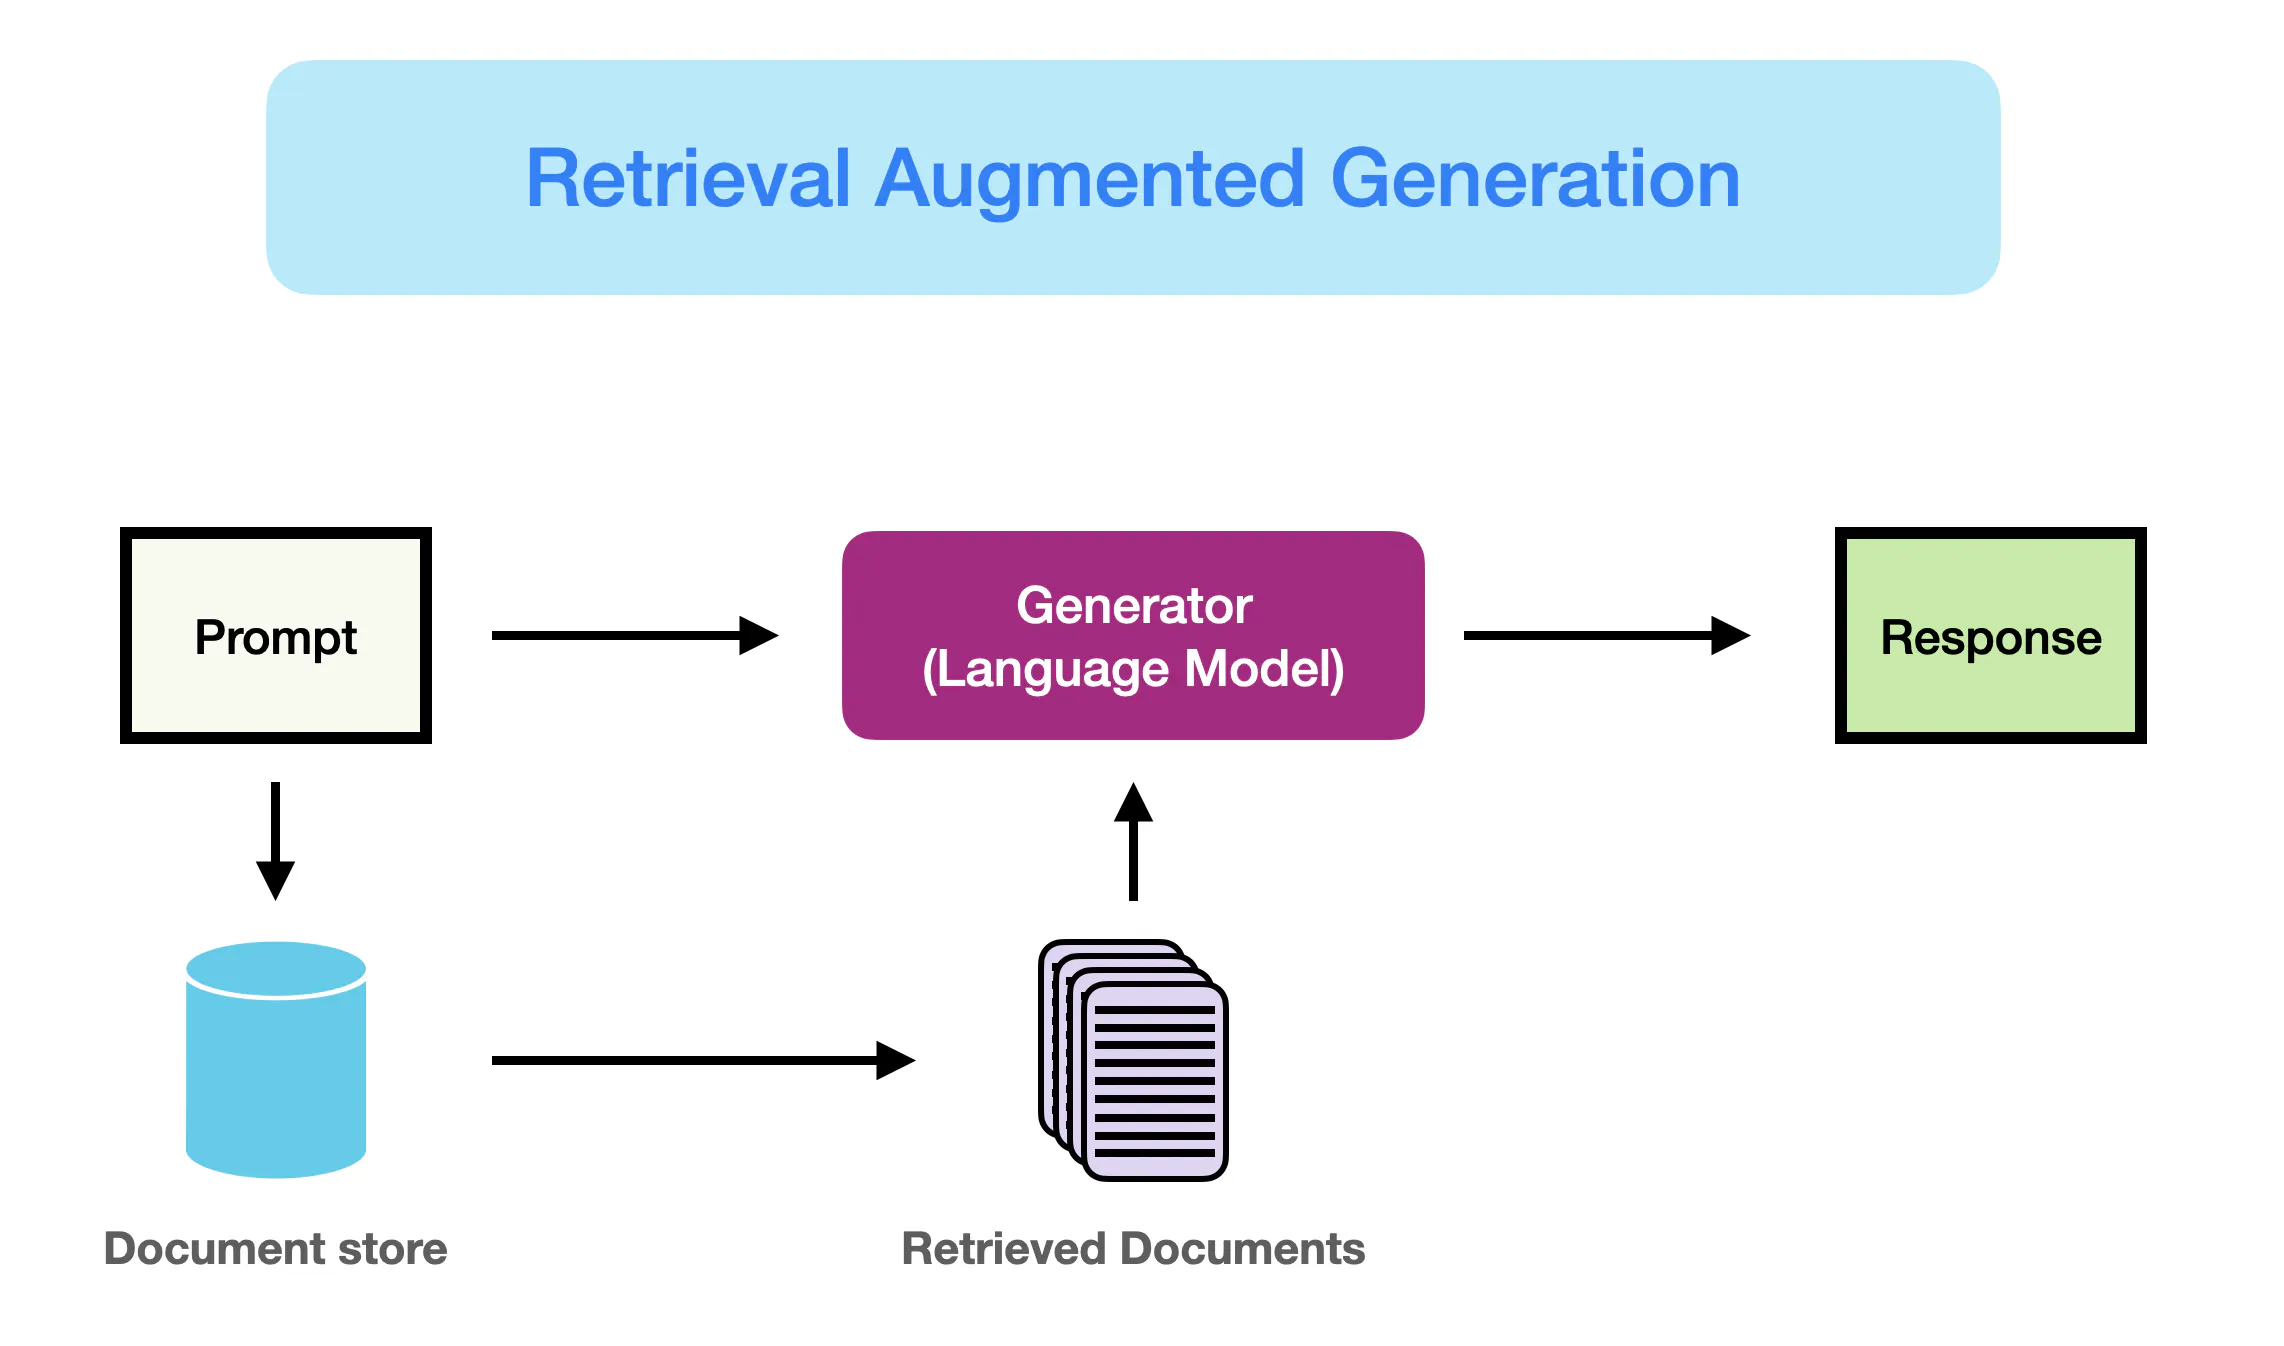

In [ ]:
#Plantilla de Prompt:
template="""
Se te proporcionará una serie de textos que dan instrucciones acerca de como resolver preguntas a un estudiante de la universidad Nacional, de acuerdo a estos textos responde a la pregunta de la manera más completa posible. Redactame una respuesta que sea lo más fiel posible a los textos que te estoy entregando.

Dado el siguiente contexto, responde a las preguntas hechas por el humano:

{context}

Human: {human_input}
Chatbot (RESPUESTA FORMAL):

"""

#Entradas a el Prompt:
prompt=PromptTemplate(input_variables=["context","human_input"],template=template)

In [ ]:
#Se define cadaena para conversación:
chain=load_qa_chain(ChatOpenAI(model_name="gpt-3.5-turbo",temperature=0.5),prompt=prompt)

In [ ]:
pregunta=input("Pregunta: ")

Pregunta: Cúales son las funciones de un sistema de puesta a tierra?


In [ ]:
#Recuperación del contexto para responder la pregunta:
docs = vectorstore_chroma.similarity_search(pregunta,k=5)
docs

[Document(metadata={'page': 2, 'source': '/content/puesta_a_tierra.pdf'}, page_content='Losobjetivosdeunsistemadepuestaatierra–SPTson: Laseguridaddelaspersonas,laproteccióndelasinstalacionesylacompatibilidadelectromagnética.Lasfuncionesdeunsistemadepuestaatierrason:\n● Garantizarcondicionesdeseguridadalosseresvivos.● Permitiralosequiposdeproteccióndespejarrápidamentelasfallas.● Servirdereferenciacomúnal sistemaeléctrico.● Conducir ydisipar consuficientecapacidadlascorrientesdefalla, electrostáticayderayo.● TransmitirseñalesdeRFenondamediaylarga.\n Realizar una conexióndebajaresistenciaconlatierrayconpuntosdereferenciadelosequipos.\nSe debe tener presente que el criterio fundamental para garantizar la seguridad de losseres humanos es la máxima energía eléctrica que pueden soportar, debida a lastensiones de paso, de contacto o transferidas y no el valor de resistencia de puesta atierratomadoaisladamente.Sinembargo,unbajovalordelaresistenciadepuestaatierraes siempre deseable para disminui

In [ ]:
#Readcción de la Respuesta a Partir del Contexto:
response=chain({"input_documents":docs,"human_input":pregunta})
response

{'input_documents': [Document(metadata={'page': 2, 'source': '/content/puesta_a_tierra.pdf'}, page_content='Losobjetivosdeunsistemadepuestaatierra–SPTson: Laseguridaddelaspersonas,laproteccióndelasinstalacionesylacompatibilidadelectromagnética.Lasfuncionesdeunsistemadepuestaatierrason:\n● Garantizarcondicionesdeseguridadalosseresvivos.● Permitiralosequiposdeproteccióndespejarrápidamentelasfallas.● Servirdereferenciacomúnal sistemaeléctrico.● Conducir ydisipar consuficientecapacidadlascorrientesdefalla, electrostáticayderayo.● TransmitirseñalesdeRFenondamediaylarga.\n Realizar una conexióndebajaresistenciaconlatierrayconpuntosdereferenciadelosequipos.\nSe debe tener presente que el criterio fundamental para garantizar la seguridad de losseres humanos es la máxima energía eléctrica que pueden soportar, debida a lastensiones de paso, de contacto o transferidas y no el valor de resistencia de puesta atierratomadoaisladamente.Sinembargo,unbajovalordelaresistenciadepuestaatierraes siempre de

In [ ]:
response["output_text"]

'Las funciones de un sistema de puesta a tierra son garantizar condiciones de seguridad a los seres vivos, permitir a los equipos de protección despejar rápidamente las fallas, servir de referencia común al sistema eléctrico, conducir y disipar con suficiente capacidad las corrientes de falla, electrostática y de rayo, así como transmitir señales de RF en onda media y larga. Además, se debe realizar una conexión de baja resistencia con la tierra y con puntos de referencia de los equipos. Es importante tener en cuenta que el criterio fundamental para garantizar la seguridad de los seres humanos es la máxima energía eléctrica que pueden soportar, debido a las tensiones de paso, de contacto o transferidas, y no únicamente el valor de resistencia de puesta a tierra tomado aisladamente. Un bajo valor de resistencia de puesta a tierra es deseable para disminuir la máxima elevación de potencial o GPR (Ground Potential Rise).'

In [ ]:
pregunta=input("Pregunta: ")

Pregunta: Cúal es la capital de Colombia?


In [ ]:
#Readcción de la Respuesta a Partir del Contexto:
response=chain({"input_documents":[],"human_input":pregunta})["output_text"]
response

'Para responder a la pregunta sobre la capital de Colombia, es importante tener en cuenta que la capital de Colombia es Bogotá. Esta ciudad es la sede del gobierno nacional y es considerada el centro político, económico, administrativo, industrial, artístico, cultural, deportivo y turístico del país. Bogotá es una ciudad con una rica historia y una diversidad cultural que la convierten en un importante punto de referencia en América Latina.'

## Memoria a Corto y Largo Plazo:

**Memoria a Largo Plazo:** Es aquel conocimiento que intrinsecamente el modelo posee; ya que fue entrenado con dichos datos o dicho conocimiento.

**Memoria a Corto Plazo:** Es aquel contexto que le proporcionamos al LLM acerca de las interacciones anteriores através de un prompt.

In [ ]:
#Introduciendo la Memoria a Corto Plazo en el Prompt:
#Plantilla de Prompt:
template="""
Se te proporcionará una serie de textos que dan instrucciones a cerca de como resolver preguntas a un estudiante de la universidad Nacional de Colombia, de acuerdo a estos textos responde a la pregunta de la manera más completa posible.

Dado el siguiente contexto y teniendo en cuenta eñ historial de la conversación, responde a las preguntas hechas por el humano:

{context}

{chat_history}
Human: {human_input}
Chatbot (RESPUESTA FORMAL):

"""

#Entradas a el Prompt:
prompt=PromptTemplate(input_variables=["chat_history","context","human_input"],template=template)

In [ ]:
#Definiendo elemento de memoria a corto plazo:
memory=ConversationBufferMemory(memory_key="chat_history",input_key="human_input")

<ipython-input-58-54b542181113>:2: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory=ConversationBufferMemory(memory_key="chat_history",input_key="human_input")


In [ ]:
#Se define cadaena para conversación:
chain=load_qa_chain(ChatOpenAI(model_name="gpt-3.5-turbo",temperature=0),prompt=prompt,memory=memory)

In [ ]:
pregunta=input("Pregunta: ")

Pregunta: Mi nombre es Santiago, tengo 22 años y soy ingeniero, puedes decirme cual es el objetivo de un sistema de puesta a tierra?


In [ ]:
#Readcción de la Respuesta a Partir del Contexto:
response=chain({"input_documents":docs,"human_input":pregunta,"chat_history":memory})["output_text"]
response

'El objetivo de un sistema de puesta a tierra es garantizar la seguridad de las personas, proteger las instalaciones y asegurar la compatibilidad electromagnética. Las funciones de un sistema de puesta a tierra incluyen garantizar condiciones de seguridad para los seres vivos, permitir a los equipos de protección despejar rápidamente las fallas, servir como referencia común al sistema eléctrico, conducir y disipar con suficiente capacidad las corrientes de falla, electrostáticas y de rayo, así como transmitir señales de RF en onda media y larga. Es importante tener en cuenta que el criterio fundamental para garantizar la seguridad de las personas es la máxima energía eléctrica que pueden soportar, debido a las tensiones de paso, de contacto o transferidas, y no el valor de resistencia de puesta a tierra tomado aisladamente. Sin embargo, un bajo valor de resistencia de puesta a tierra es siempre deseable para disminuir la máxima elevación de potencial o GPR (Ground Potential Rise).'

In [ ]:
pregunta=input("Pregunta: ")

Pregunta: Quién es Santiago?


In [ ]:
#Recuperación del contexto para responder la pregunta:
docs = vectorstore_chroma.similarity_search(pregunta,k=5)

In [ ]:
#Readcción de la Respuesta a Partir del Contexto:
response=chain({"input_documents":docs,"human_input":pregunta,"chat_history":memory})["output_text"]
response

'Santiago es un estudiante de 22 años que se identifica como ingeniero.'

In [ ]:
chain.memory

ConversationBufferMemory(chat_memory=InMemoryChatMessageHistory(messages=[HumanMessage(content='Mi nombre es Santiago, tengo 22 años y soy ingeniero, puedes decirme cual es el objetivo de un sistema de puesta a tierra?', additional_kwargs={}, response_metadata={}), AIMessage(content='El objetivo de un sistema de puesta a tierra es garantizar la seguridad de las personas, proteger las instalaciones y asegurar la compatibilidad electromagnética. Las funciones de un sistema de puesta a tierra incluyen garantizar condiciones de seguridad para los seres vivos, permitir a los equipos de protección despejar rápidamente las fallas, servir como referencia común al sistema eléctrico, conducir y disipar con suficiente capacidad las corrientes de falla, electrostáticas y de rayo, así como transmitir señales de RF en onda media y larga. Es importante tener en cuenta que el criterio fundamental para garantizar la seguridad de las personas es la máxima energía eléctrica que pueden soportar, debido a 

## Ejercicios:

1. Qué pasa si el elemento de memoria se vuelve muy extenso? En tal caso consultar e implementar:
- Summary Memory.
- Buffer-Summary Memory.

2. Será que todas las preguntas tienen k=5 fragmentos de textos relacionados? Implementar un sistema de RAG Adaptativo; para esto se debe implementar un LLM que filtre los fragmentos de texto que en realidad son relevantes a la hora de responder la pregunta hecha por el usuario.

3. Implementar un Chatbot con memoria a corto plazo que responda preguntas acerca de alguna normativa eléctrica.